In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [25]:
import pandas as pd
import math
from phe import paillier
from haversine import haversine

# Load the dataset
data = pd.read_csv("places.csv") 

# Geofence parameters
center_lat = 50.381813
center_lon = -4.127100
geofence_radius = 1.0  # km

# Step 1: Key Generation 
public_key, private_key = paillier.generate_paillier_keypair()

# Define a function for privacy-preserving haversine distance
def is_within_geofence(lat_A, lon_A, geofence_radius, lat_B, lon_B):
    # Convert degrees to radians
    latA = math.radians(lat_A)
    lonA = math.radians(lon_A)
    latB = math.radians(lat_B)
    lonB = math.radians(lon_B)

    # Compute trigonometric values
    alpha = math.cos(latA / 2)
    beta = math.sin(latB / 2)
    gamma = math.sin(latA / 2)
    delta = math.cos(latB / 2)
    zeta = math.cos(latA)
    eta = math.cos(latB)
    theta = math.sin(lonA / 2)
    lambda_ = math.cos(lonB / 2)
    mu = math.cos(lonA / 2)
    nu = math.sin(lonB / 2)

    # Computes encrypted values
    enc_alpha_squared = public_key.encrypt(alpha**2)
    enc_neg_two_alpha_gamma = public_key.encrypt(-2 * alpha * gamma)
    enc_gamma_squared = public_key.encrypt(gamma**2)
    enc_zeta_eta_theta_lambda_squared = public_key.encrypt(zeta * eta * (theta**2) * (lambda_**2))
    enc_neg_two_zeta_eta_theta_lambda = public_key.encrypt(-2 * zeta * eta * theta * lambda_)
    enc_zeta_mu = public_key.encrypt(zeta * mu**2)

    # Computes encrypted distance
    beta_squared = beta**2
    delta_squared = delta**2
    mu_nu = mu * nu
    eta_nu_squared = eta * nu**2

    enc_a = (
        enc_alpha_squared * beta_squared +
        enc_neg_two_alpha_gamma * (beta * delta) +
        enc_gamma_squared * delta_squared +
        enc_zeta_eta_theta_lambda_squared +
        enc_neg_two_zeta_eta_theta_lambda * mu_nu +
        enc_zeta_mu * eta_nu_squared
    )

    # Decrypts a
    a = private_key.decrypt(enc_a)

    # Compute haversine distance
    R = 6371.0  # Earth's radius in km
    distance = 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return distance <= geofence_radius, distance

# Iterate through the dataset
for index, row in data.iterrows():
    point_lat = row['latitude']
    point_lon = row['longitude']

    inside, dist = is_within_geofence(center_lat, center_lon, geofence_radius, point_lat, point_lon)

    if inside:
        print(f"{row['name']} is INSIDE the geofence (distance: {dist:.2f} km).")
    else:
        print(f"{row['name']} is OUTSIDE the geofence (distance: {dist:.2f} km).")


Aldi is INSIDE the geofence (distance: 0.40 km).
plymotuh collage is INSIDE the geofence (distance: 0.75 km).
train plymouth is OUTSIDE the geofence (distance: 1.30 km).
lipson co-operative academy is OUTSIDE the geofence (distance: 1.09 km).
hyde park junior school is INSIDE the geofence (distance: 0.81 km).
food4u is INSIDE the geofence (distance: 0.48 km).


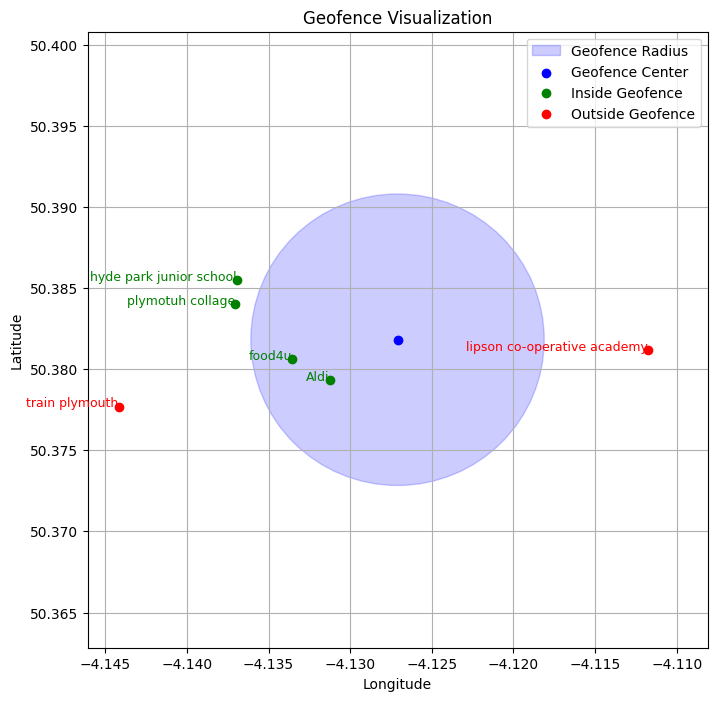

In [32]:
from math import pi
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("places.csv")

# Geofence parameters
center_lat = 50.381813
center_lon = -4.127100
geofence_radius = 1.0  # km
#radius_deg = (0.5/6371) * (180 / pi)  
radius_deg = geofence_radius/111.32

# Function to classify points
inside_points = []
outside_points = []

for index, row in data.iterrows():
    point_lat = row['latitude']
    point_lon = row['longitude']

    # Use your existing function to check if it's inside the geofence
    inside, dist = is_within_geofence(center_lat, center_lon, geofence_radius, point_lat, point_lon)

    if inside:
        inside_points.append((point_lat, point_lon , row['name']))
    else:
        outside_points.append((point_lat, point_lon , row['name']))

def plot_geofence_and_points(center_lat, center_lon, radius_km, inside_points, outside_points):

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the geofence
    geofence_circle = plt.Circle((center_lon, center_lat), radius_deg, color='blue', alpha=0.2, label="Geofence Radius")
    ax.add_patch(geofence_circle)

    # Plot the center of the geofence
    ax.scatter(center_lon, center_lat, color='blue', label="Geofence Center", zorder=5)

    # Plot points inside the geofence
    for lat, lon, name in inside_points:
        ax.scatter(lon, lat, color='green', label="Inside Geofence" if 'Inside Geofence' not in ax.get_legend_handles_labels()[1] else "", zorder=5)
        ax.text(lon, lat, name, fontsize=9, color='green', ha='right')

    # Plot points outside the geofence
    for lat, lon, name in outside_points:
        ax.scatter(lon, lat, color='red', label="Outside Geofence" if 'Outside Geofence' not in ax.get_legend_handles_labels()[1] else "", zorder=5)
        ax.text(lon, lat, name, fontsize=9, color='red', ha='right')

    # Add labels and legend
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Geofence Visualization")
    ax.legend()

    # Set limits
    margin = 0.01
    ax.set_xlim(center_lon - radius_deg - margin, center_lon + radius_deg + margin)
    ax.set_ylim(center_lat - radius_deg - margin, center_lat + radius_deg + margin)

    plt.grid()
    plt.show()

# Call the plotting function
plot_geofence_and_points(center_lat, center_lon, geofence_radius, inside_points, outside_points)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


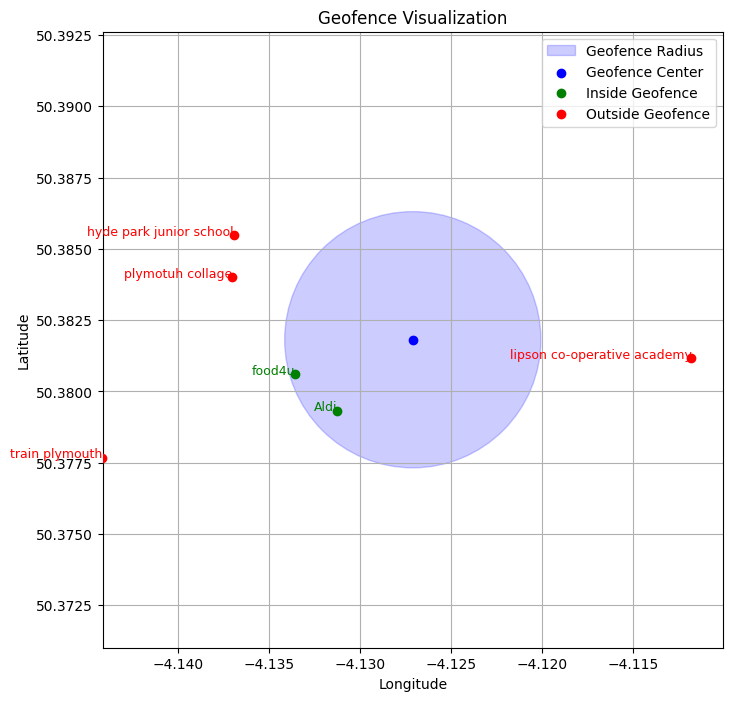

In [38]:
from math import pi, cos, radians
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Load the dataset
data = pd.read_csv("places.csv")

# Geofence parameters
center_lat = 50.381813
center_lon = -4.127100
geofence_radius = 0.5  # km

# Calculate radius in degrees for latitude and longitude
radius_deg_lat = geofence_radius / 111.32
radius_deg_lon = geofence_radius / (111.32 * cos(radians(center_lat)))

# Function to classify points
inside_points = []
outside_points = []

for index, row in data.iterrows():
    point_lat = row['latitude']
    point_lon = row['longitude']

    # Assume is_within_geofence uses proper distance calculation (e.g., Haversine)
    inside, dist = is_within_geofence(center_lat, center_lon, geofence_radius, point_lat, point_lon)

    if inside:
        inside_points.append((point_lat, point_lon, row['name']))
    else:
        outside_points.append((point_lat, point_lon, row['name']))

def plot_geofence_and_points(center_lat, center_lon, radius_km, inside_points, outside_points):
    # Calculate radii again for plotting
    radius_deg_lat = radius_km / 111.32
    radius_deg_lon = radius_km / (111.32 * cos(radians(center_lat)))

    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the geofence as an ellipse
    geofence_ellipse = Ellipse(
        (center_lon, center_lat),
        width=2 * radius_deg_lon,
        height=2 * radius_deg_lat,
        color='blue', alpha=0.2, label="Geofence Radius"
    )
    ax.add_patch(geofence_ellipse)

    # Plot center
    ax.scatter(center_lon, center_lat, color='blue', label="Geofence Center", zorder=5)

    # Plot points
    for lat, lon, name in inside_points:
        ax.scatter(lon, lat, color='green', label="Inside Geofence" if 'Inside Geofence' not in ax.get_legend_handles_labels()[1] else "", zorder=5)
        ax.text(lon, lat, name, fontsize=9, color='green', ha='right')

    for lat, lon, name in outside_points:
        ax.scatter(lon, lat, color='red', label="Outside Geofence" if 'Outside Geofence' not in ax.get_legend_handles_labels()[1] else "", zorder=5)
        ax.text(lon, lat, name, fontsize=9, color='red', ha='right')

    # Configure plot
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Geofence Visualization")
    
    # Set aspect ratio to display the ellipse correctly
    ax.set_aspect(1.0 / cos(radians(center_lat)), adjustable='datalim')
    
    # Set limits with margin
    margin = 0.01
    ax.set_xlim(center_lon - radius_deg_lon - margin, center_lon + radius_deg_lon + margin)
    ax.set_ylim(center_lat - radius_deg_lat - margin, center_lat + radius_deg_lat + margin)
    
    ax.legend()
    plt.grid()
    plt.show()

# Call the plotting function
plot_geofence_and_points(center_lat, center_lon, geofence_radius, inside_points, outside_points)
